# Natural Language Processing

In [1]:
# LOAD NLP-READY MANUALLY VALIDATED DATASET

import pandas as pd
import numpy as np
import re

from blended_learning.config.settings import settings

df = pd.read_csv(
    settings.root / "data" / "processed" / "nlp_ready_manual_validated.csv",
    encoding="utf-8-sig"
)

print(f"NLP-ready dataset loaded: {df.shape}")
display(df.head())

NLP-ready dataset loaded: (420, 109)


,gender,age,is_itc_student,itc_campus,province,itc_student_id,education_level,department,faculty,academic_year,...,open_strengths_deep_translated,open_challenges_suggestions_deep_translated,open_strengths_nllb_quality,open_strengths_deep_quality,open_strengths_manual_validated_translation,open_challenges_suggestions_nllb_quality,open_challenges_suggestions_deep_quality,open_challenges_suggestions_manual_validated_translation,open_strengths_final_en,open_challenges_suggestions_final_en
0,Male,36,True,ITC Phnom Penh (Main Campus),Phnom Penh,e20210528,Year5 - Final Year,GIC,NaN,2021–2022,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Male,23,True,ITC Phnom Penh (Main Campus),Phnom Penh,e20210686,Year5 - Final Year,GIC,NaN,2025–2026,...,Nothing,Nothing,NaN,NaN,NaN,NaN,NaN,NaN,Nothing,Nothing
2,Male,19,True,ITC Phnom Penh (Main Campus),Phnom Penh,e20241146,Year2 - Sophomore,Foundation Year,NaN,2024–2025,...,"Very good, excellent","No big challenge, i’m the best",NaN,NaN,NaN,NaN,NaN,NaN,"Very good, excellent","No big challenge, i’m the best"
3,Female,19,True,ITC Phnom Penh (Main Campus),Phnom Penh,e20240609,Year2 - Sophomore,GIC,NaN,2024–2025,...,Will try hard,Lack of self-discipline,NaN,NaN,NaN,NaN,NaN,NaN,Will try hard,Lack of self-discipline
4,Female,18,True,ITC Phnom Penh (Main Campus),Phnom Penh,e20240542,Year2 - Sophomore,GIC,NaN,2024–2025,...,getting more experience,Discipline on daily studying,NaN,NaN,NaN,NaN,NaN,NaN,getting more experience,Discipline on daily studying


In [2]:
# Select NLP columns


nlp_text_cols = [
    "open_strengths_final_en",
    "open_challenges_suggestions_final_en"
]

base_cols = [
    "student_id",
    "student_segment",
    "student_segment_label",
    "cluster_label"
]

base_cols = [c for c in base_cols if c in df.columns]

nlp_df = df[base_cols + nlp_text_cols].copy()

print(f"NLP dataframe shape: {nlp_df.shape}")
display(nlp_df.head())

NLP dataframe shape: (420, 6)


,student_id,student_segment,student_segment_label,cluster_label,open_strengths_final_en,open_challenges_suggestions_final_en
0,e20210528,2,Cluster 2: Highly Engaged (Active) Learners,Highly Engaged (Active) Learners,NaN,NaN
1,e20210686,1,Cluster 1: Moderately Engaged (Passive) Learners,Moderately Engaged (Passive) Learners,Nothing,Nothing
2,e20241146,2,Cluster 2: Highly Engaged (Active) Learners,Highly Engaged (Active) Learners,"Very good, excellent","No big challenge, i’m the best"
3,e20240609,2,Cluster 2: Highly Engaged (Active) Learners,Highly Engaged (Active) Learners,Will try hard,Lack of self-discipline
4,e20240542,1,Cluster 1: Moderately Engaged (Passive) Learners,Moderately Engaged (Passive) Learners,getting more experience,Discipline on daily studying


In [3]:

# BASIC TEXT CLEANING

import re
import pandas as pd

def clean_basic_text(text):
    if pd.isna(text):
        return ""

    text = str(text).lower().strip()
    text = re.sub(r"\s+", " ", text)

    text = text.replace("face to face", "in_person")
    text = text.replace("face-to-face", "in_person")
    text = text.replace("face face", "in_person")

    text = text.replace("self study", "self_study")
    text = text.replace("self studying", "self_study")
    text = text.replace("self learning", "self_learning")
    text = text.replace("time management", "time_management")
    text = text.replace("internet connection", "internet_connection")
    text = text.replace("internet access", "internet_access")
    text = text.replace("technical issues", "technical_issues")
    text = text.replace("online learning", "online_learning")
    text = text.replace("blended learning", "blended_learning")
    text = text.replace("saving time", "save_time")

    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [4]:
# Apply basic cleaning to the relevant columns
nlp_df["open_strengths_clean"] = (
    nlp_df["open_strengths_final_en"]
    .apply(clean_basic_text)
)

nlp_df["open_challenges_clean"] = (
    nlp_df["open_challenges_suggestions_final_en"]
    .apply(clean_basic_text)
)

## CUSTOM STOPWORDS FOR TF-IDF

In [5]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Merge sklearn and the custom words in the config.json

custom_stopwords = set(ENGLISH_STOP_WORDS).union(settings.custom_stopwords)

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# Expand multi-word stopwords into sklearn-tokenized single words
analyzer = CountVectorizer().build_analyzer()

expanded_stopwords = set(custom_stopwords)

for word in custom_stopwords:
    expanded_stopwords.update(analyzer(word))

custom_stopwords = sorted(expanded_stopwords)

In [7]:
# TF-IDF keyword extraction function

def get_top_tfidf_keywords(df, text_col, top_n=20, ngram_range=(1, 2)):
    texts = df[text_col].fillna("").astype(str)
    texts = texts[texts.str.strip() != ""]

    vectorizer = TfidfVectorizer(
        stop_words=list(custom_stopwords),
        ngram_range=ngram_range,
        min_df=2,
        max_df=0.90
    )

    tfidf_matrix = vectorizer.fit_transform(texts)
    feature_names = vectorizer.get_feature_names_out()
    scores = tfidf_matrix.sum(axis=0).A1

    keyword_df = pd.DataFrame({
        "keyword": feature_names,
        "tfidf_score": scores
    })

    keyword_df["keyword"] = (
        keyword_df["keyword"]
        .str.replace("_", " ", regex=False)
    )

    keyword_df = keyword_df.sort_values(
        by="tfidf_score",
        ascending=False
    ).head(top_n)

    return keyword_df


## BIGRAM TF-IDF KEYWORD EXTRACTION


In [8]:
strengths_keywords = get_top_tfidf_keywords(
    nlp_df,
    "open_strengths_clean",
    top_n=20,
    ngram_range=(2, 2)
)

challenges_keywords = get_top_tfidf_keywords(
    nlp_df,
    "open_challenges_clean",
    top_n=20,
    ngram_range=(2, 2)
)

print("Top TF-IDF keywords and phrases: strengths")
display(strengths_keywords)

print("Top TF-IDF keywords and phrases: challenges/suggestions")
display(challenges_keywords)

Top TF-IDF keywords and phrases: strengths


,keyword,tfidf_score
0,access materials,7.152046
67,learn pace,5.944949
28,digital skills,5.324284
91,review anytime,4.718916
72,materials anytime,4.212252
42,flexibility review,4.019531
29,digital tools,3.432816
39,flexibility learn,3.429659
33,flexibility access,3.323506
1,access resources,3.314258


Top TF-IDF keywords and phrases: challenges/suggestions


,keyword,tfidf_score
36,internet issues,8.769492
57,lack motivation,8.292984
4,ask questions,6.816320
115,unstable internet connection,5.096916
72,pay attention,4.567649
108,technical problems,4.145240
41,internet slow,4.033141
33,internet connectivity,3.716080
12,difficulty staying,3.665205
46,internet connection difficulty,3.490295


The TF-IDF score represents the relative importance of a keyword or phrase within the dataset. A higher score indicates that the term appears frequently in students’ responses while remaining relatively unique, making it a strong indicator of key themes.

In [9]:
# MAP THEMES TO SYSTEM-READY DEFINITIONS
strength_theme_map = settings.strength_theme_map

challenge_theme_map = settings.challenge_theme_map


In [10]:
def build_theme_summary(keyword_df, theme_map):
    rows = []

    for theme, keywords in theme_map.items():
        matched = keyword_df[keyword_df["keyword"].isin(keywords)]

        if not matched.empty:
            rows.append({
                "theme": theme,
                "keywords": ", ".join(matched["keyword"]),
                "total_score": matched["tfidf_score"].sum(),
                "keyword_count": len(matched)
            })

    if len(rows) == 0:
        return pd.DataFrame(
            columns=["theme", "keywords", "total_score", "keyword_count"]
        )

    return (
        pd.DataFrame(rows)
        .sort_values(by="total_score", ascending=False)
        .reset_index(drop=True)
    )

In [11]:
strength_theme_summary = build_theme_summary(
    strengths_keywords, strength_theme_map
)

challenge_theme_summary = build_theme_summary(
    challenges_keywords, challenge_theme_map
)

display(strength_theme_summary)
display(challenge_theme_summary)

,theme,keywords,total_score,keyword_count
0,Digital Skills Development,"digital skills, digital tools",8.757101,2
1,Access to Learning Materials,access materials,7.152046,1
2,Flexibility & Time Management,"learn anytime, flexible schedule",4.237436,2
3,Student Engagement,ask questions,3.274248,1


,theme,keywords,total_score,keyword_count
0,Internet & Technical Issues,"internet issues, technical problems, internet ...",30.047964,7
1,Motivation & Self-Discipline,"lack motivation, pay attention, lack discipline",15.803109,3
2,Interaction & Communication,"ask questions, lack interaction, interactive a...",13.140911,3
3,Learning Difficulty & Clarity,unclear instructions,3.339110,1


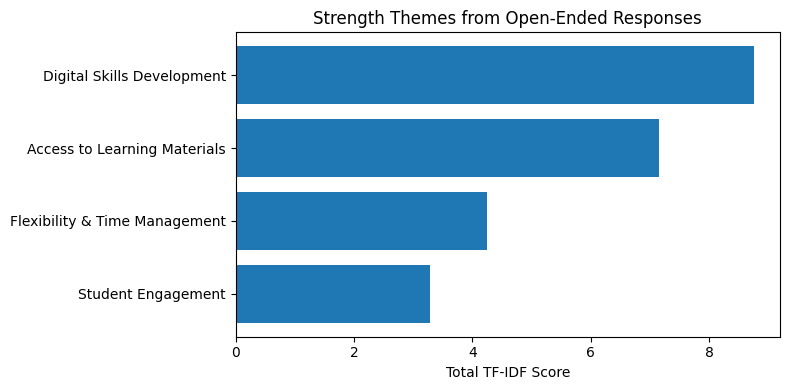

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.barh(
    strength_theme_summary["theme"],
    strength_theme_summary["total_score"]
)
plt.xlabel("Total TF-IDF Score")
plt.title("Strength Themes from Open-Ended Responses")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

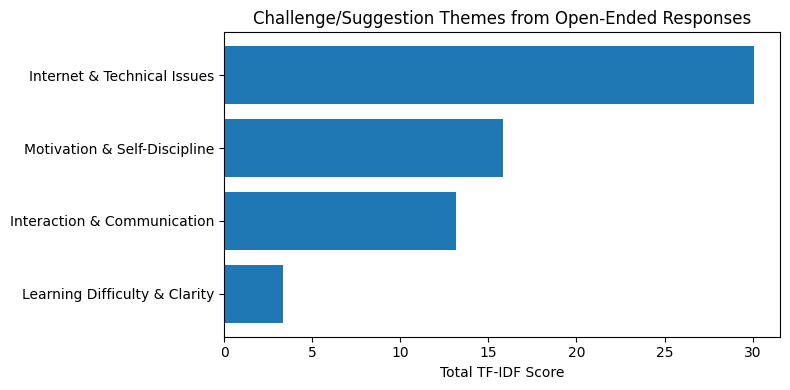

In [13]:
plt.figure(figsize=(8, 4))
plt.barh(
    challenge_theme_summary["theme"],
    challenge_theme_summary["total_score"]
)
plt.xlabel("Total TF-IDF Score")
plt.title("Challenge/Suggestion Themes from Open-Ended Responses")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [14]:
#  mapping themes to recommendation categories
theme_to_recommendation_map = settings.theme_to_recommendation_map


In [15]:
def get_student_tags(keywords):
    tags = set()

    for theme, kw_list in {**strength_theme_map, **challenge_theme_map}.items():
        if any(k in keywords for k in kw_list):
            tags.add(theme_to_recommendation_map.get(theme))

    return list(tags)

# Tie themes with clusters


In [16]:
# =========================================================
# CLUSTER-BASED THEME EXTRACTION
# =========================================================

cluster_col = "student_segment"
cluster_label_col = "student_segment_label"

def build_cluster_theme_summary(
    df,
    cluster_col,
    cluster_label_col,
    text_col,
    theme_map,
    top_n_keywords=30
):
    all_rows = []

    for cluster in sorted(df[cluster_col].dropna().unique()):
        subset = df[df[cluster_col] == cluster]

        if subset.shape[0] < 2:
            continue

        cluster_label = subset[cluster_label_col].iloc[0]

        keyword_df = get_top_tfidf_keywords(
            subset,
            text_col,
            top_n=top_n_keywords,
            ngram_range=(2, 2)
        )

        theme_summary = build_theme_summary(keyword_df, theme_map)

        for _, row in theme_summary.iterrows():
            all_rows.append({
            "cluster": cluster,
            "cluster_label": cluster_label,
            "theme": row["theme"],
            "keywords": row["keywords"],
            "total_score": row["total_score"],
            "keyword_count": row["keyword_count"],
            "n_students": subset.shape[0]
    })

    return pd.DataFrame(all_rows)

In [17]:
cluster_strength_themes = build_cluster_theme_summary(
    nlp_df,
    cluster_col,
    cluster_label_col,
    "open_strengths_clean",
    strength_theme_map
)

display(cluster_strength_themes)

,cluster,cluster_label,theme,keywords,total_score,keyword_count,n_students
0,1,Cluster 1: Moderately Engaged (Passive) Learners,Digital Skills Development,"digital skills, digital skill, digital tools",6.763068,3,171
1,1,Cluster 1: Moderately Engaged (Passive) Learners,Access to Learning Materials,access materials,2.000000,1,171
2,1,Cluster 1: Moderately Engaged (Passive) Learners,Flexibility & Time Management,learn anytime,1.475047,1,171
3,1,Cluster 1: Moderately Engaged (Passive) Learners,Student Engagement,ask questions,1.458879,1,171
4,2,Cluster 2: Highly Engaged (Active) Learners,Digital Skills Development,"digital tools, digital skills",5.556293,2,249
5,2,Cluster 2: Highly Engaged (Active) Learners,Access to Learning Materials,access materials,5.339873,1,249
6,2,Cluster 2: Highly Engaged (Active) Learners,Flexibility & Time Management,flexible schedule,2.000000,1,249
7,2,Cluster 2: Highly Engaged (Active) Learners,Student Engagement,ask questions,1.927235,1,249


In [18]:
cluster_challenge_themes = build_cluster_theme_summary(
    nlp_df,
    cluster_col,
    cluster_label_col,
    "open_challenges_clean",
    challenge_theme_map
)

display(cluster_challenge_themes)

,cluster,cluster_label,theme,keywords,total_score,keyword_count,n_students
0,1,Cluster 1: Moderately Engaged (Passive) Learners,Internet & Technical Issues,"internet issues, internet connectivity, unstab...",18.279241,7,171
1,1,Cluster 1: Moderately Engaged (Passive) Learners,Motivation & Self-Discipline,"lack motivation, lost track",7.757722,2,171
2,1,Cluster 1: Moderately Engaged (Passive) Learners,Interaction & Communication,"lack interaction, interactive activities",3.970297,2,171
3,1,Cluster 1: Moderately Engaged (Passive) Learners,Learning Difficulty & Clarity,unclear instructions,2.317957,1,171
4,2,Cluster 2: Highly Engaged (Active) Learners,Internet & Technical Issues,"internet issues, internet problems, technical ...",15.864092,6,249
5,2,Cluster 2: Highly Engaged (Active) Learners,Interaction & Communication,"ask questions, interactive activities, lack co...",11.519553,4,249
6,2,Cluster 2: Highly Engaged (Active) Learners,Motivation & Self-Discipline,"pay attention, lack motivation, lack discipline",10.124603,3,249
7,2,Cluster 2: Highly Engaged (Active) Learners,Learning Difficulty & Clarity,"difficulty understanding, explain clearly, unc...",6.088170,3,249


In [19]:
display(
    cluster_strength_themes.sort_values(
        ["cluster", "total_score"],
        ascending=[True, False]
    )
)

display(
    cluster_challenge_themes.sort_values(
        ["cluster", "total_score"],
        ascending=[True, False]
    )
)

,cluster,cluster_label,theme,keywords,total_score,keyword_count,n_students
0,1,Cluster 1: Moderately Engaged (Passive) Learners,Digital Skills Development,"digital skills, digital skill, digital tools",6.763068,3,171
1,1,Cluster 1: Moderately Engaged (Passive) Learners,Access to Learning Materials,access materials,2.000000,1,171
2,1,Cluster 1: Moderately Engaged (Passive) Learners,Flexibility & Time Management,learn anytime,1.475047,1,171
3,1,Cluster 1: Moderately Engaged (Passive) Learners,Student Engagement,ask questions,1.458879,1,171
4,2,Cluster 2: Highly Engaged (Active) Learners,Digital Skills Development,"digital tools, digital skills",5.556293,2,249
5,2,Cluster 2: Highly Engaged (Active) Learners,Access to Learning Materials,access materials,5.339873,1,249
6,2,Cluster 2: Highly Engaged (Active) Learners,Flexibility & Time Management,flexible schedule,2.000000,1,249
7,2,Cluster 2: Highly Engaged (Active) Learners,Student Engagement,ask questions,1.927235,1,249


,cluster,cluster_label,theme,keywords,total_score,keyword_count,n_students
0,1,Cluster 1: Moderately Engaged (Passive) Learners,Internet & Technical Issues,"internet issues, internet connectivity, unstab...",18.279241,7,171
1,1,Cluster 1: Moderately Engaged (Passive) Learners,Motivation & Self-Discipline,"lack motivation, lost track",7.757722,2,171
2,1,Cluster 1: Moderately Engaged (Passive) Learners,Interaction & Communication,"lack interaction, interactive activities",3.970297,2,171
3,1,Cluster 1: Moderately Engaged (Passive) Learners,Learning Difficulty & Clarity,unclear instructions,2.317957,1,171
4,2,Cluster 2: Highly Engaged (Active) Learners,Internet & Technical Issues,"internet issues, internet problems, technical ...",15.864092,6,249
5,2,Cluster 2: Highly Engaged (Active) Learners,Interaction & Communication,"ask questions, interactive activities, lack co...",11.519553,4,249
6,2,Cluster 2: Highly Engaged (Active) Learners,Motivation & Self-Discipline,"pay attention, lack motivation, lack discipline",10.124603,3,249
7,2,Cluster 2: Highly Engaged (Active) Learners,Learning Difficulty & Clarity,"difficulty understanding, explain clearly, unc...",6.088170,3,249


Excellent — this is exactly the result you need. Now you can interpret **how the two student clusters differ**.

## Key findings from your cluster-based themes

### Cluster 1: Moderately Engaged (Passive) Learners

**Strengths**
Their strongest positive theme is:

> **Access to Learning Materials**
> total score = 11.02

This means passive/moderately engaged students mainly value blended learning because they can access and review materials anytime.

Their next themes are:

> **Flexibility & Time Management**
> total score = 6.04

> **Digital Skills Development**
> total score = 4.76

So this group benefits from flexible learning, but their engagement-related strength is weaker:

> **Student Engagement**
> total score = 1.46

This makes sense because they are labeled as moderately engaged/passive learners.

---

### Cluster 2: Highly Engaged (Active) Learners

**Strengths**
Their strongest positive theme is also:

> **Access to Learning Materials**
> total score = 12.42

But compared with Cluster 1, Cluster 2 shows stronger results in:

> **Flexibility & Time Management**
> total score = 8.54

> **Digital Skills Development**
> total score = 5.56

> **Student Engagement**
> total score = 3.93

This means highly engaged students are not only using materials, but also benefiting more from flexibility, digital tools, and active participation.

---

## Challenge comparison

### Cluster 1 challenges

The biggest challenge is:

> **Internet & Technical Issues**
> total score = 15.45

Other challenges:

> **Motivation & Self-Discipline**
> total score = 6.00

> **Learning Difficulty & Clarity**
> total score = 4.61

> **Interaction & Communication**
> total score = 3.97

For Cluster 1, the main issue is technical access, followed by motivation.

---

### Cluster 2 challenges

The biggest challenge is also:

> **Internet & Technical Issues**
> total score = 15.59

But Cluster 2 has stronger challenge scores in:

> **Learning Difficulty & Clarity**
> total score = 9.97

> **Interaction & Communication**
> total score = 9.52

> **Motivation & Self-Discipline**
> total score = 8.53

This is interesting. Even though they are highly engaged, they still report many challenges. This may mean they are more active, more aware of learning problems, and more likely to express detailed feedback.

---

## Thesis interpretation

You can write:

> The cluster-based theme analysis shows that both student segments identified access to learning materials as the main strength of blended learning. However, highly engaged learners showed stronger associations with flexibility, digital skills development, and student engagement, suggesting that active learners are better able to take advantage of blended learning opportunities.
>
> In terms of challenges, both clusters reported internet and technical issues as the dominant concern. However, highly engaged learners also showed stronger concern with learning clarity, interaction, and motivation. This suggests that active learners may be more reflective and more likely to identify specific barriers affecting their learning experience.
>
> Meanwhile, moderately engaged learners showed weaker engagement-related themes, indicating that this group may require more structured support, motivation strategies, and interaction opportunities.

## How this supports your recommendation system

Use this mapping:

| Cluster                                | Main needs                                     | Suggested recommendation                                                                                        |
| -------------------------------------- | ---------------------------------------------- | --------------------------------------------------------------------------------------------------------------- |
| Cluster 1: Moderately Engaged Learners | Motivation, structure, interaction             | Provide reminders, weekly learning plans, short guided activities, and more teacher check-ins                   |
| Cluster 2: Highly Engaged Learners     | Better clarity, interaction, technical support | Provide advanced learning materials, clear instructions, interactive activities, and reliable technical support |

Your result is strong because it connects:

```text
Cluster profile → NLP themes → student needs → recommendation rules
```


# VADER SENTIMENT ANALYSIS

In [20]:

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

In [21]:
def get_vader_sentiment(text):
    if pd.isna(text) or str(text).strip() == "":
        return pd.Series({
            "neg": 0,
            "neu": 0,
            "pos": 0,
            "compound": 0,
            "sentiment_label": "neutral"
        })

    scores = analyzer.polarity_scores(str(text))
    compound = scores["compound"]

    if compound >= 0.05:
        label = "positive"
    elif compound <= -0.05:
        label = "negative"
    else:
        label = "neutral"

    return pd.Series({
        "neg": scores["neg"],
        "neu": scores["neu"],
        "pos": scores["pos"],
        "compound": compound,
        "sentiment_label": label
    })

In [22]:
# Strength / positive-aspect sentiment
strength_sentiment = (
    nlp_df["open_strengths_final_en"]
    .apply(get_vader_sentiment)
    .add_prefix("strength_")
)

# Challenge / suggestion sentiment
challenge_sentiment = (
    nlp_df["open_challenges_suggestions_final_en"]
    .apply(get_vader_sentiment)
    .add_prefix("challenge_")
)

nlp_df = pd.concat(
    [nlp_df, strength_sentiment, challenge_sentiment],
    axis=1
)

display(nlp_df.head())

,student_id,student_segment,student_segment_label,cluster_label,open_strengths_final_en,open_challenges_suggestions_final_en,open_strengths_clean,open_challenges_clean,strength_neg,strength_neu,strength_pos,strength_compound,strength_sentiment_label,challenge_neg,challenge_neu,challenge_pos,challenge_compound,challenge_sentiment_label
0,e20210528,2,Cluster 2: Highly Engaged (Active) Learners,Highly Engaged (Active) Learners,NaN,NaN,,,0.000,0.000,0.000,0.0000,neutral,0.000,0.000,0.000,0.0000,neutral
1,e20210686,1,Cluster 1: Moderately Engaged (Passive) Learners,Moderately Engaged (Passive) Learners,Nothing,Nothing,nothing,nothing,0.000,1.000,0.000,0.0000,neutral,0.000,1.000,0.000,0.0000,neutral
2,e20241146,2,Cluster 2: Highly Engaged (Active) Learners,Highly Engaged (Active) Learners,"Very good, excellent","No big challenge, i’m the best",very good excellent,no big challenge i m the best,0.000,0.122,0.878,0.8004,positive,0.322,0.282,0.395,0.4172,positive
3,e20240609,2,Cluster 2: Highly Engaged (Active) Learners,Highly Engaged (Active) Learners,Will try hard,Lack of self-discipline,will try hard,lack of self discipline,0.412,0.588,0.000,-0.1027,negative,0.535,0.465,0.000,-0.3182,negative
4,e20240542,1,Cluster 1: Moderately Engaged (Passive) Learners,Moderately Engaged (Passive) Learners,getting more experience,Discipline on daily studying,getting more experience,discipline on daily studying,0.000,1.000,0.000,0.0000,neutral,0.000,1.000,0.000,0.0000,neutral


In [23]:
print("Strength sentiment distribution")
display(nlp_df["strength_sentiment_label"].value_counts())

print("Challenge / suggestion sentiment distribution")
display(nlp_df["challenge_sentiment_label"].value_counts())

Strength sentiment distribution


strength_sentiment_label
positive    286
neutral     109
negative     25
Name: count, dtype: int64

Challenge / suggestion sentiment distribution


challenge_sentiment_label
positive    165
negative    132
neutral     123
Name: count, dtype: int64

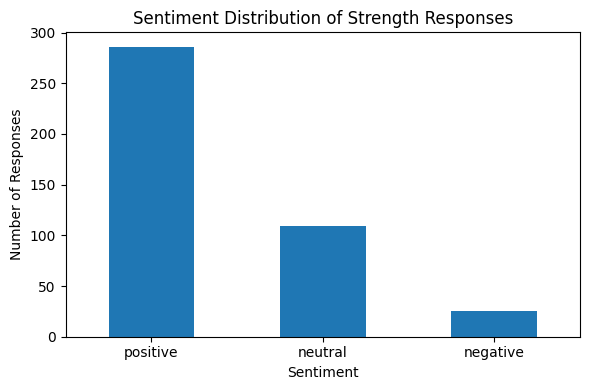

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
nlp_df["strength_sentiment_label"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution of Strength Responses")
plt.xlabel("Sentiment")
plt.ylabel("Number of Responses")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

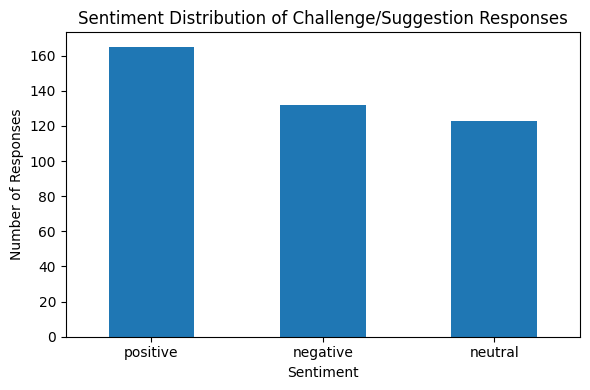

In [25]:
plt.figure(figsize=(6, 4))
nlp_df["challenge_sentiment_label"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution of Challenge/Suggestion Responses")
plt.xlabel("Sentiment")
plt.ylabel("Number of Responses")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [26]:
strength_sentiment_by_cluster = pd.crosstab(
    nlp_df["student_segment_label"],
    nlp_df["strength_sentiment_label"],
    normalize="index"
) * 100

challenge_sentiment_by_cluster = pd.crosstab(
    nlp_df["student_segment_label"],
    nlp_df["challenge_sentiment_label"],
    normalize="index"
) * 100

print("Strength sentiment by cluster (%)")
display(strength_sentiment_by_cluster.round(2))

print("Challenge / suggestion sentiment by cluster (%)")
display(challenge_sentiment_by_cluster.round(2))

Strength sentiment by cluster (%)


strength_sentiment_label,negative,neutral,positive
student_segment_label,,,
Cluster 1: Moderately Engaged (Passive) Learners,7.02,28.65,64.33
Cluster 2: Highly Engaged (Active) Learners,5.22,24.10,70.68


Challenge / suggestion sentiment by cluster (%)


challenge_sentiment_label,negative,neutral,positive
student_segment_label,,,
Cluster 1: Moderately Engaged (Passive) Learners,27.49,28.65,43.86
Cluster 2: Highly Engaged (Active) Learners,34.14,29.72,36.14


In [27]:
sentiment_cluster_summary = (
    nlp_df
    .groupby("student_segment_label")[
        ["strength_compound", "challenge_compound"]
    ]
    .mean()
    .reset_index()
)

display(sentiment_cluster_summary)

,student_segment_label,strength_compound,challenge_compound
0,Cluster 1: Moderately Engaged (Passive) Learners,0.314431,0.127830
1,Cluster 2: Highly Engaged (Active) Learners,0.380798,0.047178


_ Cluster 2 = more positive about benefits
_ Cluster 2 = also more critical about challenges
_ Cluster 1 = less expressive / more moderate

In [29]:
# =========================================================
# EXPORT STUDENT-LEVEL RECOMMENDATION FEATURES
# NLP TAGS + SEGMENT FALLBACK TAGS
# =========================================================

import os
import re
import json
import pandas as pd


# ---------------------------------------------------------
# 1. Text normalization
# ---------------------------------------------------------

def normalize_text_for_matching(text):
    if pd.isna(text):
        return ""

    text = str(text).lower()
    text = text.replace("_", " ")
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text


def is_non_meaningful_response(text):
    text_norm = normalize_text_for_matching(text)

    non_meaningful = {
        "",
        "no",
        "none",
        "nothing",
        "no comment",
        "not sure",
        "no idea",
        "don t know",
        "dont know",
        "don t have",
        "dont have",
        "not yet",
        "n a",
        "na",
        "nil",
        "ok",
        "okay",
        "agree",
        "all good",
        "everything is good",
        "it already great",
        "nope",
        "math",
        "french",
        "coding",
        "sad",
        "uyu",
        "uu",
        "nuh uhh",
        "dunno yet"
    }

    return text_norm in non_meaningful


# ---------------------------------------------------------
# 2. Student-level theme detection
# ---------------------------------------------------------

def detect_themes(text, theme_map):
    """
    Detect themes from one student's cleaned response.
    """
    if is_non_meaningful_response(text):
        return []

    text_norm = normalize_text_for_matching(text)
    matched_themes = []

    for theme, keywords in theme_map.items():
        for keyword in keywords:
            keyword_norm = normalize_text_for_matching(keyword)

            if keyword_norm and keyword_norm in text_norm:
                matched_themes.append(theme)
                break

    return sorted(list(set(matched_themes)))


def themes_to_tags(themes):
    """
    Convert detected themes into recommendation tags.
    """
    tags = []

    for theme in themes:
        tag = theme_to_recommendation_map.get(theme)

        if tag is not None:
            tags.append(tag)

    return sorted(list(set(tags)))


# ---------------------------------------------------------
# 3. Create NLP-based themes and tags
# ---------------------------------------------------------

nlp_df["strength_themes"] = nlp_df["open_strengths_clean"].apply(
    lambda x: detect_themes(x, strength_theme_map)
)

nlp_df["challenge_themes"] = nlp_df["open_challenges_clean"].apply(
    lambda x: detect_themes(x, challenge_theme_map)
)

nlp_df["strength_tags"] = nlp_df["strength_themes"].apply(themes_to_tags)

nlp_df["challenge_tags"] = nlp_df["challenge_themes"].apply(themes_to_tags)

nlp_df["recommendation_tags"] = nlp_df.apply(
    lambda row: sorted(
        list(
            set(row["strength_tags"] + row["challenge_tags"])
        )
    ),
    axis=1
)


# ---------------------------------------------------------
# 4. Segment-based fallback tags
# ---------------------------------------------------------

def get_segment_default_tags(segment_label):
    """
    Segment fallback tags.
    Used only when NLP-based recommendation_tags are empty.
    """
    if pd.isna(segment_label):
        return []

    label = str(segment_label).lower()

    if "cluster 1" in label or "passive" in label or "moderately engaged" in label:
        return [
            "motivation",
            "interaction",
            "learning_support",
            "self_paced"
        ]

    if "cluster 2" in label or "active" in label or "highly engaged" in label:
        return [
            "content_access",
            "engagement",
            "digital_skill",
            "self_paced"
        ]

    return []


nlp_df["segment_default_tags"] = nlp_df["student_segment_label"].apply(
    get_segment_default_tags
)


def create_final_recommendation_tags(row):
    """
    Use NLP tags if available.
    If NLP tags are empty, use segment fallback tags.
    """
    nlp_tags = row["recommendation_tags"]
    fallback_tags = row["segment_default_tags"]

    if isinstance(nlp_tags, list) and len(nlp_tags) > 0:
        return sorted(list(set(nlp_tags)))

    return sorted(list(set(fallback_tags)))


nlp_df["final_recommendation_tags"] = nlp_df.apply(
    create_final_recommendation_tags,
    axis=1
)


# ---------------------------------------------------------
# 5. Rule-based recommendation text
# ---------------------------------------------------------

recommendation_rule_bank = {
    "tech_issue": {
        "title": "Improve technical access and reliability",
        "recommendation": "Provide stable internet access, offline materials, clear platform instructions, and technical support."
    },
    "motivation": {
        "title": "Support motivation and self-discipline",
        "recommendation": "Use weekly check-ins, reminders, progress tracking, and structured study schedules."
    },
    "interaction": {
        "title": "Increase interaction and communication",
        "recommendation": "Add Q&A sessions, group discussion, peer collaboration, and faster lecturer feedback."
    },
    "learning_support": {
        "title": "Improve clarity and learning support",
        "recommendation": "Provide clearer instructions, examples, recorded explanations, and step-by-step learning guides."
    },
    "learning_environment": {
        "title": "Improve learning resources and environment",
        "recommendation": "Organize materials clearly, update resources, improve study spaces, and support classroom comfort."
    },
    "workload_support": {
        "title": "Manage workload and assessment pressure",
        "recommendation": "Balance assignments, clarify deadlines, and align online tasks with in-person sessions."
    },
    "self_paced": {
        "title": "Support self-paced learning",
        "recommendation": "Provide recorded lessons, weekly learning paths, and materials students can review at their own pace."
    },
    "content_access": {
        "title": "Strengthen access to learning materials",
        "recommendation": "Upload slides, videos, references, exercises, and course materials early."
    },
    "digital_skill": {
        "title": "Develop digital learning skills",
        "recommendation": "Provide guidance on LMS tools, online resources, digital research, and educational technologies."
    },
    "engagement": {
        "title": "Increase learner engagement",
        "recommendation": "Use quizzes, games, practical tasks, discussions, and interactive activities."
    },
    "learning_effectiveness": {
        "title": "Improve learning effectiveness",
        "recommendation": "Combine online review materials with in-person explanation, practice, and feedback."
    }
}


def build_rule_based_recommendations(tags):
    recommendations = []

    for tag in tags:
        if tag in recommendation_rule_bank:
            recommendations.append({
                "tag": tag,
                "title": recommendation_rule_bank[tag]["title"],
                "recommendation": recommendation_rule_bank[tag]["recommendation"]
            })

    return recommendations


nlp_df["rule_based_recommendations"] = nlp_df["final_recommendation_tags"].apply(
    build_rule_based_recommendations
)


# ---------------------------------------------------------
# 6. Convert list/dict columns to JSON strings for CSV
# ---------------------------------------------------------

json_cols = [
    "strength_themes",
    "challenge_themes",
    "strength_tags",
    "challenge_tags",
    "recommendation_tags",
    "segment_default_tags",
    "final_recommendation_tags",
    "rule_based_recommendations"
]

for col in json_cols:
    nlp_df[col] = nlp_df[col].apply(
        lambda x: json.dumps(x, ensure_ascii=False)
    )


# ---------------------------------------------------------
# 7. Select final export columns
# ---------------------------------------------------------

recommendation_feature_cols = [
    "student_id",
    "student_segment",
    "student_segment_label",
    "cluster_label",

    "open_strengths_final_en",
    "open_challenges_suggestions_final_en",
    "open_strengths_clean",
    "open_challenges_clean",

    "strength_sentiment_label",
    "challenge_sentiment_label",
    "strength_compound",
    "challenge_compound",

    "strength_themes",
    "challenge_themes",
    "strength_tags",
    "challenge_tags",

    "recommendation_tags",
    "segment_default_tags",
    "final_recommendation_tags",
    "rule_based_recommendations"
]

recommendation_feature_cols = [
    col for col in recommendation_feature_cols
    if col in nlp_df.columns
]

student_recommendation_features = nlp_df[
    recommendation_feature_cols
].copy()


# ---------------------------------------------------------
# 8. Export CSV
# ---------------------------------------------------------

output_path = settings.root / "data" / "processed" / "student_recommendation_features.csv"

student_recommendation_features.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig"
)

print("Student recommendation feature dataset exported successfully.")
print(f"Saved to: {output_path}")
print(f"Shape: {student_recommendation_features.shape}")

display(student_recommendation_features.head(10))


Student recommendation feature dataset exported successfully.
Saved to: C:\Users\Tepy\Documents\tepy\Final Internship Docs\blended_learning\data\processed\student_recommendation_features.csv
Shape: (420, 20)


,student_id,student_segment,student_segment_label,cluster_label,open_strengths_final_en,open_challenges_suggestions_final_en,open_strengths_clean,open_challenges_clean,strength_sentiment_label,challenge_sentiment_label,strength_compound,challenge_compound,strength_themes,challenge_themes,strength_tags,challenge_tags,recommendation_tags,segment_default_tags,final_recommendation_tags,rule_based_recommendations
0,e20210528,2,Cluster 2: Highly Engaged (Active) Learners,Highly Engaged (Active) Learners,NaN,NaN,,,neutral,neutral,0.0000,0.0000,[],[],[],[],[],"[""content_access"", ""engagement"", ""digital_skil...","[""content_access"", ""digital_skill"", ""engagemen...","[{""tag"": ""content_access"", ""title"": ""Strengthe..."
1,e20210686,1,Cluster 1: Moderately Engaged (Passive) Learners,Moderately Engaged (Passive) Learners,Nothing,Nothing,nothing,nothing,neutral,neutral,0.0000,0.0000,[],[],[],[],[],"[""motivation"", ""interaction"", ""learning_suppor...","[""interaction"", ""learning_support"", ""motivatio...","[{""tag"": ""interaction"", ""title"": ""Increase int..."
2,e20241146,2,Cluster 2: Highly Engaged (Active) Learners,Highly Engaged (Active) Learners,"Very good, excellent","No big challenge, i’m the best",very good excellent,no big challenge i m the best,positive,positive,0.8004,0.4172,"[""Learning Convenience & Effectiveness""]",[],"[""learning_effectiveness""]",[],"[""learning_effectiveness""]","[""content_access"", ""engagement"", ""digital_skil...","[""learning_effectiveness""]","[{""tag"": ""learning_effectiveness"", ""title"": ""I..."
3,e20240609,2,Cluster 2: Highly Engaged (Active) Learners,Highly Engaged (Active) Learners,Will try hard,Lack of self-discipline,will try hard,lack of self discipline,negative,negative,-0.1027,-0.3182,[],"[""Motivation & Self-Discipline""]",[],"[""motivation""]","[""motivation""]","[""content_access"", ""engagement"", ""digital_skil...","[""motivation""]","[{""tag"": ""motivation"", ""title"": ""Support motiv..."
4,e20240542,1,Cluster 1: Moderately Engaged (Passive) Learners,Moderately Engaged (Passive) Learners,getting more experience,Discipline on daily studying,getting more experience,discipline on daily studying,neutral,neutral,0.0000,0.0000,"[""Learning Convenience & Effectiveness""]","[""Motivation & Self-Discipline""]","[""learning_effectiveness""]","[""motivation""]","[""learning_effectiveness"", ""motivation""]","[""motivation"", ""interaction"", ""learning_suppor...","[""learning_effectiveness"", ""motivation""]","[{""tag"": ""learning_effectiveness"", ""title"": ""I..."
5,e20220287,1,Cluster 1: Moderately Engaged (Passive) Learners,Moderately Engaged (Passive) Learners,Student could retrieve the lesson once they wa...,Add Ai assistance,student could retrieve the lesson once they wa...,add ai assistance,positive,neutral,0.0772,0.0000,"[""Access to Learning Materials""]",[],"[""content_access""]",[],"[""content_access""]","[""motivation"", ""interaction"", ""learning_suppor...","[""content_access""]","[{""tag"": ""content_access"", ""title"": ""Strengthe..."
6,e20210180,1,Cluster 1: Moderately Engaged (Passive) Learners,Moderately Engaged (Passive) Learners,Innovate yourself with the technology world,Lack of resources and misinformation,innovate yourself with the technology world,lack of resources and misinformation,positive,negative,0.4939,-0.5574,"[""Digital Skills Development""]","[""Learning Resources & Environment""]","[""digital_skill""]","[""learning_environment""]","[""digital_skill"", ""learning_environment""]","[""motivation"", ""interaction"", ""learning_suppor...","[""digital_skill"", ""learning_environment""]","[{""tag"": ""digital_skill"", ""title"": ""Develop di..."
7,e20241245,1,Cluster 1: Moderately Engaged (Passive) Learners,Moderately Engaged (Passive) Learners,Blended learning has many positive aspects. It...,The biggest challenges of blended learning are...,blended_learning has many positive aspects it ...,the biggest challenges of blended_learning are...,p

In [30]:
def json_len(x):
    try:
        return len(json.loads(x))
    except Exception:
        return 0


print("Total students:", len(student_recommendation_features))

print(
    "Empty NLP recommendation_tags:",
    student_recommendation_features["recommendation_tags"]
    .apply(json_len)
    .eq(0)
    .sum()
)

print(
    "Empty final_recommendation_tags:",
    student_recommendation_features["final_recommendation_tags"]
    .apply(json_len)
    .eq(0)
    .sum()
)

Total students: 420
Empty NLP recommendation_tags: 42
Empty final_recommendation_tags: 0
